In [1]:
mkdir -p ~/.kaggle && echo KGAT_f688a39c4327eb7dc6a085eed40cc6df > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [2]:
# ============================
# CELL 1: Setup & Import
# ============================

# Install kagglehub untuk download dataset
!pip install kagglehub -q

import kagglehub
import pandas as pd
import numpy as np
import re
import string
import os
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout, GlobalMaxPool1D

print("✅ Import selesai")

2026-06-24 05:09:32.499863: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782277772.741476      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782277772.805658      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782277773.370478      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782277773.370542      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782277773.370546      58 computation_placer.cc:177] computation placer alr

✅ Import selesai


In [3]:
# ============================
# CELL 2: Load All Datasets
# ============================

# Download dataset dari Kaggle
path1 = kagglehub.dataset_download("subhajournal/phishingemails")
path2 = kagglehub.dataset_download("venky73/spam-mails-dataset")
path3 = kagglehub.dataset_download("naserabdullahalam/phishing-email-dataset")
path4 = kagglehub.dataset_download("nitishabharathi/email-spam-dataset")  # ← ganti ini

print("✅ Semua dataset berhasil didownload")

# Helper cari file CSV pertama di folder
def find_csv(base_path):
    for root, dirs, files in os.walk(base_path):
        for f in files:
            if f.endswith('.csv'):
                return os.path.join(root, f)
    return None

# Dataset 1: Subhajournal phishingemails
df1 = pd.read_csv(find_csv(path1))
df1['email'] = df1['Email Text'].astype(str)
df1['label'] = df1['Email Type'].map(lambda x: 1 if x.lower() == 'phishing email' else 0)
df1 = df1[['email', 'label']]
print(f"df1 shape: {df1.shape} | label dist:\n{df1['label'].value_counts()}")

# Dataset 2: Venky73 spam-mails-dataset
df2 = pd.read_csv(find_csv(path2))
df2['label'] = df2['label'].map(lambda x: 1 if str(x).lower() in ['phishing', 'spam', 'fraud', 'commercial spam'] else 0)
df2['email'] = df2['text'].astype(str)
df2 = df2[['email', 'label']]
print(f"df2 shape: {df2.shape} | label dist:\n{df2['label'].value_counts()}")

# Dataset 3: naserabdullahalam/phishing-email-dataset
df3_raw = pd.read_csv(find_csv(path3))
print(f"df3 columns: {df3_raw.columns.tolist()}")
# Deteksi kolom otomatis
email_col3 = next((c for c in df3_raw.columns if 'text' in c.lower() or 'email' in c.lower() or 'body' in c.lower()), None)
label_col3 = next((c for c in df3_raw.columns if 'label' in c.lower() or 'type' in c.lower() or 'class' in c.lower()), None)
df3 = pd.DataFrame()
df3['email'] = df3_raw[email_col3].astype(str)
df3['label'] = df3_raw[label_col3].map(lambda x: 1 if str(x).lower() in ['phishing', 'spam', '1', 'phishing email'] else 0)
print(f"df3 shape: {df3.shape} | label dist:\n{df3['label'].value_counts()}")

# Dataset 4: nitishabharathi/email-spam-dataset (pengganti)
df4_raw = pd.read_csv(find_csv(path4))
print(f"df4 columns: {df4_raw.columns.tolist()}")
email_col4 = next((c for c in df4_raw.columns if 'text' in c.lower() or 'email' in c.lower() or 'body' in c.lower() or 'message' in c.lower()), None)
label_col4 = next((c for c in df4_raw.columns if 'label' in c.lower() or 'type' in c.lower() or 'class' in c.lower() or 'spam' in c.lower()), None)
df4 = pd.DataFrame()
df4['email'] = df4_raw[email_col4].astype(str)
df4['label'] = df4_raw[label_col4].map(lambda x: 1 if str(x).lower() in ['phishing', 'spam', '1', 'phishing email'] else 0)
print(f"df4 shape: {df4.shape} | label dist:\n{df4['label'].value_counts()}")

✅ Semua dataset berhasil didownload
df1 shape: (18650, 2) | label dist:
label
0    11322
1     7328
Name: count, dtype: int64
df2 shape: (5171, 2) | label dist:
label
0    3672
1    1499
Name: count, dtype: int64
df3 columns: ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']
df3 shape: (5809, 2) | label dist:
label
0    4091
1    1718
Name: count, dtype: int64
df4 columns: ['Unnamed: 0', 'Body', 'Label']
df4 shape: (2605, 2) | label dist:
label
0    2172
1     433
Name: count, dtype: int64


In [4]:
df1.head()

,email,label
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",0
1,the other side of * galicismos * * galicismo *...,0
2,re : equistar deal tickets are you still avail...,0
3,\nHello I am your hot lil horny toy.\n I am...,1
4,software at incredibly low prices ( 86 % lower...,1


In [5]:
# Dataset 2: Venky73 spam-mails-dataset
path2 = kagglehub.dataset_download("venky73/spam-mails-dataset")
df2 = pd.read_csv(find_csv(path2))

# Label mapping for df2
df2['label'] = df2['label'].map(lambda x: 1 if str(x).lower() in ['phishing', 'spam', 'fraud', 'commercial spam'] else 0)
df2['email'] = df2['text'].astype(str)
print(f"df2 shape: {df2.shape}")

df2 shape: (5171, 5)


In [6]:
df2.head()

,Unnamed: 0,label,text,label_num,email
0,605,0,Subject: enron methanol ; meter # : 988291\r\n...,0,Subject: enron methanol ; meter # : 988291\r\n...
1,2349,0,"Subject: hpl nom for january 9 , 2001\r\n( see...",0,"Subject: hpl nom for january 9 , 2001\r\n( see..."
2,3624,0,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0,"Subject: neon retreat\r\nho ho ho , we ' re ar..."
3,4685,1,"Subject: photoshop , windows , office . cheap ...",1,"Subject: photoshop , windows , office . cheap ..."
4,2030,0,Subject: re : indian springs\r\nthis deal is t...,0,Subject: re : indian springs\r\nthis deal is t...


In [7]:
print(df3.columns.tolist())
print(df3.head(2))

['email', 'label']
                                               email  label
0  Date:        Wed, 21 Aug 2002 10:54:46 -0500  ...      0
1  Martin A posted:\nTassos Papadopoulos, the Gre...      0


In [8]:
# Dataset 3: Naserabdullahalam phishing-email-dataset
path3 = kagglehub.dataset_download("naserabdullahalam/phishing-email-dataset")
df3 = pd.read_csv(find_csv(path3))
df3['email'] = (df3['subject'].astype(str) + ' ' + df3['body'].astype(str))
df3['label'] = df3['label']
print(f"df3 shape: {df3.shape}")
print(df3['label'].value_counts())

df3 shape: (5809, 8)
label
0    4091
1    1718
Name: count, dtype: int64


In [9]:
df3.head()

,sender,receiver,date,subject,body,label,urls,email
0,Robert Elz <kre@munnari.OZ.AU>,Chris Garrigues <cwg-dated-1030377287.06fa6d@D...,"Thu, 22 Aug 2002 18:26:25 +0700",Re: New Sequences Window,"Date: Wed, 21 Aug 2002 10:54:46 -0500 ...",0,1,"Re: New Sequences Window Date: Wed, 21 ..."
1,Steve Burt <Steve_Burt@cursor-system.com>,"""'zzzzteana@yahoogroups.com'"" <zzzzteana@yahoo...","Thu, 22 Aug 2002 12:46:18 +0100",[zzzzteana] RE: Alexander,"Martin A posted:\nTassos Papadopoulos, the Gre...",0,1,[zzzzteana] RE: Alexander Martin A posted:\nTa...
2,"""Tim Chapman"" <timc@2ubh.com>",zzzzteana <zzzzteana@yahoogroups.com>,"Thu, 22 Aug 2002 13:52:38 +0100",[zzzzteana] Moscow bomber,Man Threatens Explosion In Moscow \n\nThursday...,0,1,[zzzzteana] Moscow bomber Man Threatens Explos...
3,Monty Solomon <monty@roscom.com>,undisclosed-recipient: ;,"Thu, 22 Aug 2002 09:15:25 -0400",[IRR] Klez: The Virus That Won't Die,Klez: The Virus That Won't Die\n \nAlready the...,0,1,[IRR] Klez: The Virus That Won't Die Klez: Th...
4,Stewart Smith <Stewart.Smith@ee.ed.ac.uk>,zzzzteana@yahoogroups.com,"Thu, 22 Aug 2002 14:38:22 +0100",Re: [zzzzteana] Nothing like mama used to make,"> in adding cream to spaghetti carbonara, whi...",0,1,Re: [zzzzteana] Nothing like mama used to make...


In [10]:
# Dataset 4: SMS Spam Collection Dataset
path4 = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")
df4 = pd.read_csv(find_csv(path4), encoding='latin1')
df4['label'] = df4['v1'].map(lambda x: 1 if x.lower() in ['phishing', 'spam', 'fraud', 'commercial spam'] else 0)
df4['email'] = df4['v2'].astype(str)
print(f"df4 shape: {df4.shape}")
print(df4['label'].value_counts())

df4 shape: (5572, 7)
label
0    4825
1     747
Name: count, dtype: int64


In [11]:
df4.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4,label,email
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN,0,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN,0,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN,0,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN,0,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
# Combine all datasets
combined_df = pd.concat([
    df1[['email', 'label']],
    df2[['email', 'label']],
    df3[['email', 'label']],
    df4[['email', 'label']],
], ignore_index=True)

In [13]:
combined_df.head()

,email,label
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",0
1,the other side of * galicismos * * galicismo *...,0
2,re : equistar deal tickets are you still avail...,0
3,\nHello I am your hot lil horny toy.\n I am...,1
4,software at incredibly low prices ( 86 % lower...,1


In [14]:
combined_df.describe()

,label
count,35202.000000
mean,0.320777
std,0.466782
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [15]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35202 entries, 0 to 35201
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   email   35202 non-null  object
 1   label   35202 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 550.2+ KB


In [16]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub('<.*?>', ' ', text)                            # Remove HTML tags
    text = re.sub(r'http\S+|www\S+', '', text)                   # Remove URLs
    text = re.sub(f"[{re.escape(string.punctuation)}]", '', text)# Remove punctuation
    text = re.sub(r'\d+', '', text)                              # Remove numbers
    text = re.sub(r'\s+', ' ', text)                             # Normalize spaces
    return text.strip()

In [17]:
combined_df['clean_email'] = combined_df['email'].apply(preprocess_text)

In [18]:
# Remove empty entries if any
combined_df = combined_df[combined_df['clean_email'].str.strip() != '']

In [19]:
combined_df.head()

,email,label,clean_email
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",0,re disc uniformitarianism re sex lang dick hud...
1,the other side of * galicismos * * galicismo *...,0,the other side of galicismos galicismo is a sp...
2,re : equistar deal tickets are you still avail...,0,re equistar deal tickets are you still availab...
3,\nHello I am your hot lil horny toy.\n I am...,1,hello i am your hot lil horny toy i am the one...
4,software at incredibly low prices ( 86 % lower...,1,software at incredibly low prices lower draper...


In [20]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35194 entries, 0 to 35201
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   email        35194 non-null  object
 1   label        35194 non-null  int64 
 2   clean_email  35194 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.1+ MB


Total samples: 35194
Label distribution:
label
0    23906
1    11288
Name: count, dtype: int64


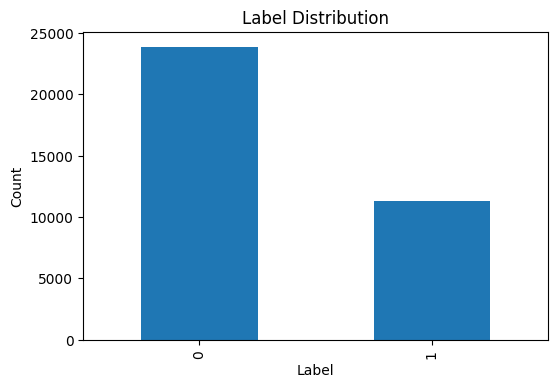

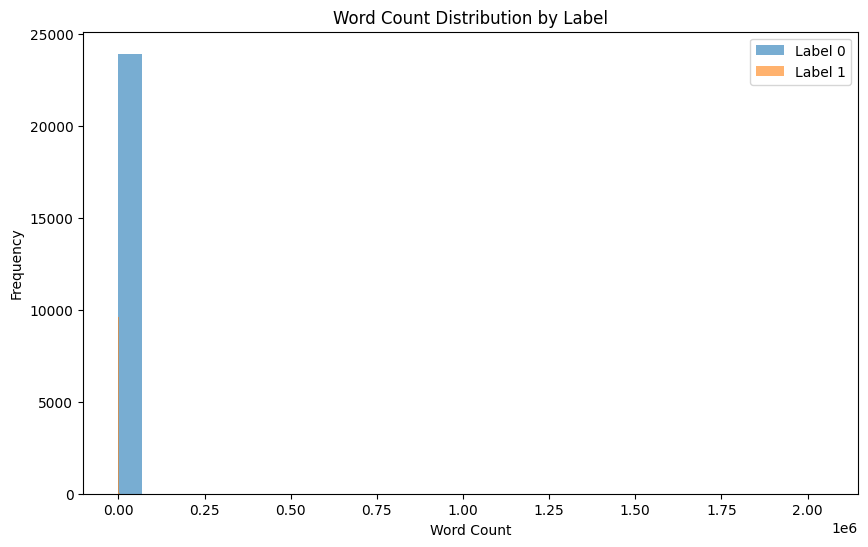

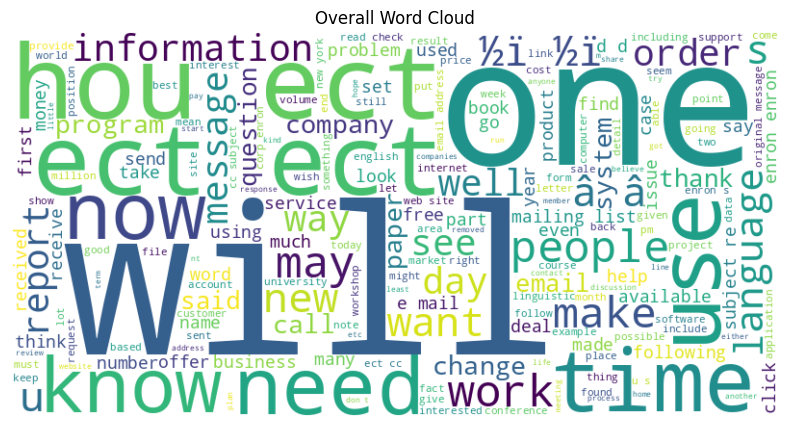

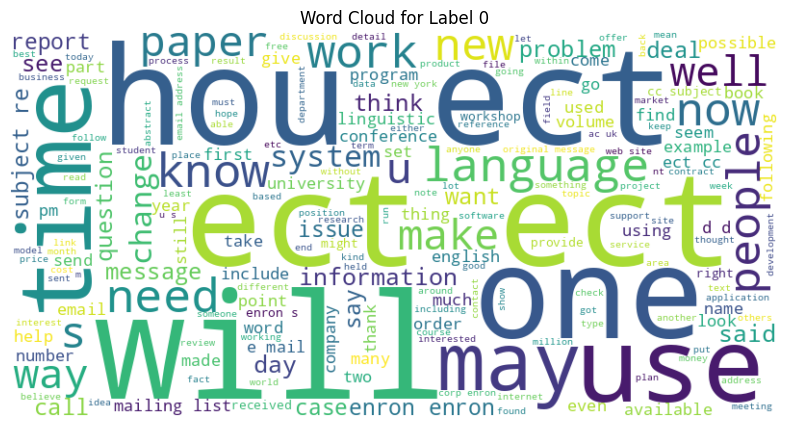

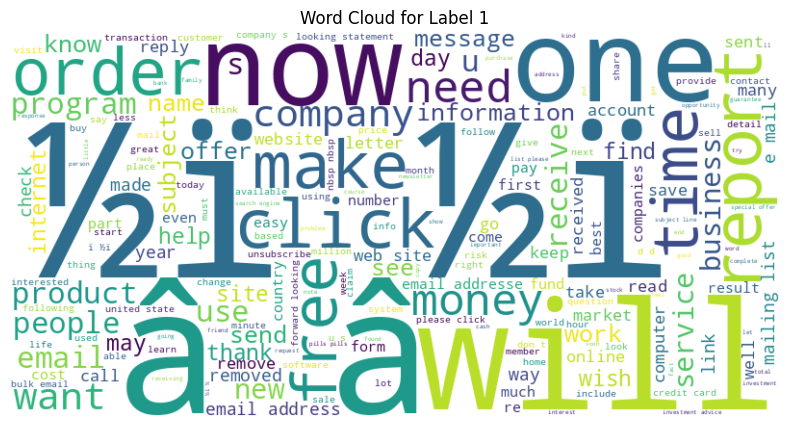

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re

# Dataset overview
print(f"Total samples: {len(combined_df)}")
print(f"Label distribution:\n{combined_df['label'].value_counts()}")

# Text length distribution
combined_df['char_count'] = combined_df['clean_email'].apply(len)
combined_df['word_count'] = combined_df['clean_email'].apply(lambda x: len(x.split()))

# Plot label distribution
plt.figure(figsize=(6,4))
combined_df['label'].value_counts().plot(kind='bar', title='Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

# Plot word count distribution by label
plt.figure(figsize=(10,6))
for label in combined_df['label'].unique():
    subset = combined_df[combined_df['label'] == label]
    plt.hist(subset['word_count'], bins=30, alpha=0.6, label=f'Label {label}')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.title('Word Count Distribution by Label')
plt.legend()
plt.show()

# Word cloud generation function
def plot_wordcloud(text, title):
    wc = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

# Word clouds overall and per label
all_text = ' '.join(combined_df['clean_email'])
plot_wordcloud(all_text, 'Overall Word Cloud')

for label in combined_df['label'].unique():
    label_text = ' '.join(combined_df[combined_df['label'] == label]['clean_email'])
    plot_wordcloud(label_text, f'Word Cloud for Label {label}')

In [22]:
texts = combined_df['clean_email'].values
labels = combined_df['label'].values

In [23]:
# Split into train and test with stratification
X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.15, random_state=42, stratify=labels)

In [24]:
# Tokenization
max_words = 20000
max_len = 300

tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

In [25]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [26]:
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

In [27]:
model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=True)),
    GlobalMaxPool1D(),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.25),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2026-06-24 05:11:16.256414: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
# --- Calculate class weights to balance training ---
cw = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)

In [29]:
# --- Train the model ---
history = model.fit(
    X_train_pad, y_train,
    epochs=6,
    batch_size=128,
    validation_data=(X_test_pad, y_test),
    class_weight={0: cw[0], 1: cw[1]}
)

Epoch 1/6
234/234 ━━━━━━━━━━━━━━━━━━━━ 139s 576ms/step - accuracy: 0.8744 - loss: 0.2715 - val_accuracy: 0.9638 - val_loss: 0.0919
Epoch 2/6
234/234 ━━━━━━━━━━━━━━━━━━━━ 134s 571ms/step - accuracy: 0.9745 - loss: 0.0725 - val_accuracy: 0.9722 - val_loss: 0.0728
Epoch 3/6
234/234 ━━━━━━━━━━━━━━━━━━━━ 133s 568ms/step - accuracy: 0.9857 - loss: 0.0406 - val_accuracy: 0.9744 - val_loss: 0.0826
Epoch 4/6
234/234 ━━━━━━━━━━━━━━━━━━━━ 133s 569ms/step - accuracy: 0.9894 - loss: 0.0295 - val_accuracy: 0.9761 - val_loss: 0.0727
Epoch 5/6
234/234 ━━━━━━━━━━━━━━━━━━━━ 135s 575ms/step - accuracy: 0.9904 - loss: 0.0237 - val_accuracy: 0.9754 - val_loss: 0.0809
Epoch 6/6
234/234 ━━━━━━━━━━━━━━━━━━━━ 134s 573ms/step - accuracy: 0.9923 - loss: 0.0189 - val_accuracy: 0.9752 - val_loss: 0.0821


In [30]:
# --- Evaluate ---
loss, acc = model.evaluate(X_test_pad, y_test)
print(f'Test Accuracy: {acc:.3f}')

165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.9752 - loss: 0.0821
Test Accuracy: 0.975


In [31]:
# --- Sample predictions ---
import numpy as np
sample_idxs = np.random.choice(len(X_test), 5, replace=False)
for idx in sample_idxs:
    print('Sample Email:', X_test[idx][:150], '...')
    print('True Label:', 'Phishing' if y_test[idx] == 1 else 'Safe')
    pred_prob = model.predict(np.expand_dims(X_test_pad[idx], axis=0))
    print('Predicted:', 'Phishing' if pred_prob > 0.5 else 'Safe')
    print('-'*60)

Sample Email: semantics syntax semantics interface language acquisition van hout angeliek event semantics of verb frame alternations a case study of dutch and its a ...
True Label: Safe
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step
Predicted: Safe
------------------------------------------------------------
Sample Email: ilug linux based ivr just wondering if anyone has implemented one before and any suggestions etc yes i am googling but would like some experienced opi ...
True Label: Safe
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Predicted: Safe
------------------------------------------------------------
Sample Email: hello hmlflk its time vacation register for one of our giveaway destinations f r e e over destinations to choose from click here to register florida e ...
True Label: Phishing
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Predicted: Phishing
------------------------------------------------------------
Sample Email: there are some nice pubs near here or there is frankie n bennys near the w

In [32]:
import os
MODEL_DIR = '/kaggle/working/'
model.save(os.path.join(MODEL_DIR, "dl_phishing_model.keras"))
print("Training complete and model saved.")

Training complete and model saved.


In [33]:
# Install tf2onnx
!pip install tf2onnx -q
print("✅ tf2onnx terinstall")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.1/839.1 kB 26.7 MB/s eta 0:00:00
✅ tf2onnx terinstall


In [34]:
import os

# 1. Export SavedModel
model.export("saved_model_phishing")

# 2. Konversi ke ONNX (sembunyikan GPU supaya tidak ada konflik CUDA)
!CUDA_VISIBLE_DEVICES="" python -m tf2onnx.convert \
    --saved-model saved_model_phishing \
    --output phishing_model.onnx \
    --opset 13

# 3. Verifikasi file berhasil dibuat
if os.path.exists("phishing_model.onnx"):
    print(f"✅ phishing_model.onnx berhasil dibuat ({os.path.getsize('phishing_model.onnx') / 1024 / 1024:.2f} MB)")
else:
    print("❌ File ONNX tidak ditemukan, cek log di atas")

INFO:tensorflow:Assets written to: saved_model_phishing/assets


INFO:tensorflow:Assets written to: saved_model_phishing/assets


Saved artifact at 'saved_model_phishing'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 300), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134199127944528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134199127946256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134199127946064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134199127948368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134199127947216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134199127948560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134199127943568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134199127948752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134198732096528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134199127946832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134198732095568: T

In [38]:
# Konstanta (sama seperti saat training)
MAX_WORDS = 10000
MAX_LEN   = 300

In [42]:
import os
import tensorflow as tf

os.environ["CUDA_VISIBLE_DEVICES"] = ""
tf.config.set_visible_devices([], 'GPU')

MAX_WORDS = 20000
MAX_LEN   = 300

with tf.device('/CPU:0'):
    model_cpu = tf.keras.Sequential([
        tf.keras.layers.Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
        tf.keras.layers.GlobalMaxPool1D(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model_cpu.build(input_shape=(None, MAX_LEN))
    model_cpu.set_weights(model.get_weights())
    model_cpu.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("✅ Model CPU siap")

model_cpu.export("saved_model_cpu")
print("✅ SavedModel CPU tersimpan")

!CUDA_VISIBLE_DEVICES="" python -m tf2onnx.convert \
    --saved-model saved_model_cpu \
    --output /kaggle/working/phishing_model_cpu.onnx \
    --opset 13

if os.path.exists("/kaggle/working/phishing_model_cpu.onnx"):
    size = os.path.getsize("/kaggle/working/phishing_model_cpu.onnx") / 1024 / 1024
    print(f"✅ Berhasil! Size: {size:.2f} MB")
    print("📥 Download dari panel Output Kaggle")
else:
    print("❌ Gagal, cek log di atas")

✅ Model CPU siap
INFO:tensorflow:Assets written to: saved_model_cpu/assets


INFO:tensorflow:Assets written to: saved_model_cpu/assets


Saved artifact at 'saved_model_cpu'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 300), dtype=tf.float32, name='keras_tensor_36')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134199104323024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134199104308048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134199104323408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134199104309008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134199104317072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134199122182992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134199122184144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134199104323216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134199122183184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134199122183952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134199122182416: Ten